Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve

Load Dataset

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "pregnancies","glucose","blood_pressure","skin_thickness",
    "insulin","bmi","diabetes_pedigree","age","outcome"
]

df = pd.read_csv(url, names=columns)

df.head()

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Exploratory Data Analysis

In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pregnancies        768 non-null    int64  
 1   glucose            768 non-null    int64  
 2   blood_pressure     768 non-null    int64  
 3   skin_thickness     768 non-null    int64  
 4   insulin            768 non-null    int64  
 5   bmi                768 non-null    float64
 6   diabetes_pedigree  768 non-null    float64
 7   age                768 non-null    int64  
 8   outcome            768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       pregnancies     glucose  blood_pressure  skin_thickness     insulin  \
count   768.000000  768.000000      768.000000      768.000000  768.000000   
mean      3.845052  120.894531       69.105469       20.536458   79.799479   
std       3.369578   31.972618       19.355807       15.952218  115.244002   


Age distribution

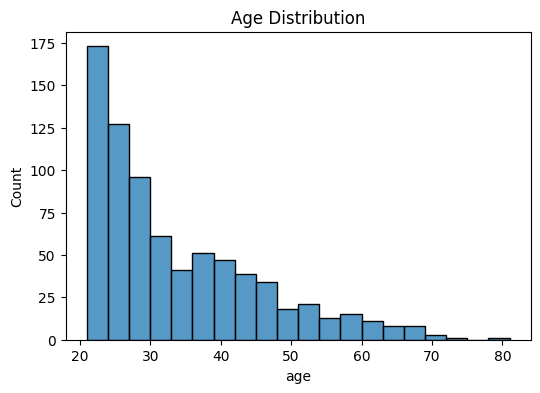

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["age"], bins=20)
plt.title("Age Distribution")
plt.show()

Correlation Heatmap

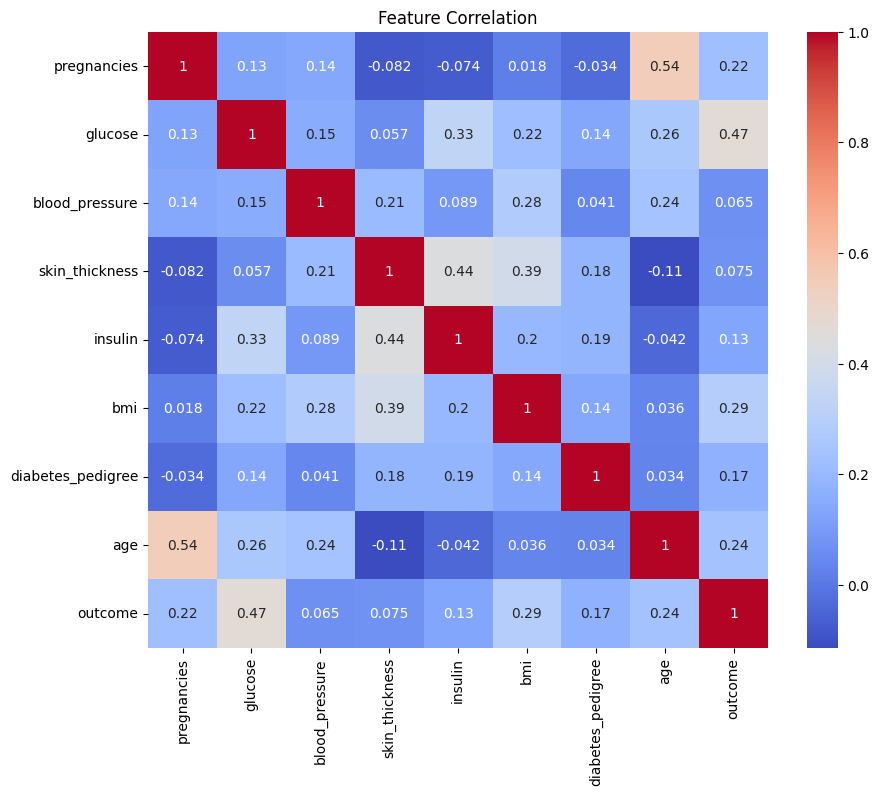

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation")
plt.show()

Data cleaning

In [ ]:
cols = ["glucose","blood_pressure","skin_thickness","insulin","bmi"]

df[cols] = df[cols].replace(0, np.nan)

df.fillna(df.mean(), inplace=True)


feature engineering

In [ ]:
df["bmi_age_interaction"] = df["bmi"] * df["age"]

train test split

In [ ]:
X = df.drop("outcome", axis=1)
y = df["outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

feature scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

train multiple models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    results.append((name, acc, auc))

    print(name)
    print("Accuracy:", acc)
    print("ROC AUC:", auc)
    print(classification_report(y_test, preds))
    print()

Logistic Regression
Accuracy: 0.7467532467532467
ROC AUC: 0.8168962350780532
              precision    recall  f1-score   support

           0       0.80      0.81      0.80        99
           1       0.65      0.64      0.64        55

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154


Random Forest
Accuracy: 0.7207792207792207
ROC AUC: 0.8206611570247934
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154


SVM
Accuracy: 0.7662337662337663
ROC AUC: 0.8084481175390266
              precision    recall  f1-score   support

           0       0.79      0.87      0.83        99
           1       0.71   

model comparison table

In [ ]:
results_df = pd.DataFrame(results, columns=["Model","Accuracy","ROC_AUC"])

results_df

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.746753,0.816896
1,Random Forest,0.720779,0.820661
2,SVM,0.766234,0.808448


confusion matrix

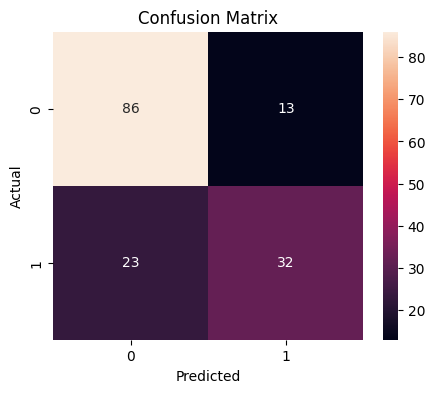

In [ ]:
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

roc curve

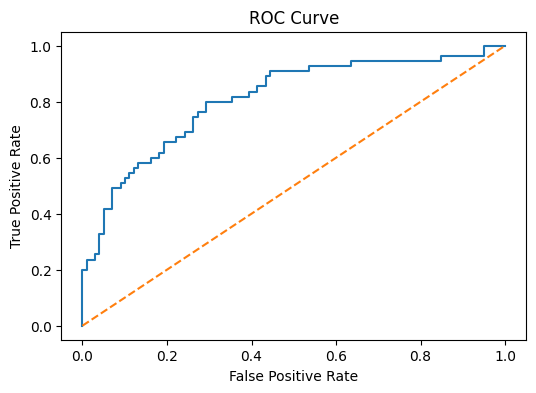

In [ ]:
fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()